In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

print("Please select and upload your Nassau Candy Distributor Excel dataset:")
uploaded = files.upload()

# Get the filename dynamically
filename = list(uploaded.keys())[0]
print(f"Successfully uploaded: {filename}")

Please select and upload your Nassau Candy Distributor Excel dataset:


Saving Final Nassau Candy Distributor.xlsx to Final Nassau Candy Distributor (2).xlsx
Successfully uploaded: Final Nassau Candy Distributor (2).xlsx


In [ ]:
# 1. Load the dataset
df = pd.read_excel(filename)

# 2. Format Date columns to Datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# 3. Handle Product-to-Factory Mapping (From Instructions Table)
factory_mapping = {
    'Wonka Bar - Nutty Crunch Surprise': "Lot's O' Nuts",
    'Wonka Bar - Fudge Mallows': "Lot's O' Nuts",
    'Wonka Bar -Scrumdiddlyumptious': "Lot's O' Nuts",
    'Wonka Bar - Milk Chocolate': "Wicked Choccy's",
    'Wonka Bar - Triple Dazzle Caramel': "Wicked Choccy's",
    'Laffy Taffy': 'Sugar Shack',
    'SweeTARTS': 'Sugar Shack',
    'Nerds': 'Sugar Shack',
    'Fun Dip': 'Sugar Shack',
    'Fizzy Lifting Drinks': 'Sugar Shack',
    'Everlasting Gobstopper': 'Secret Factory',
    'Hair Toffee': 'The Other Factory',
    'Lickable Wallpaper': 'Secret Factory',
    'Wonka Gum': 'Secret Factory',
    'Kazookles': 'The Other Factory'
}
df['Factory'] = df['Product Name'].map(factory_mapping)

# 4. Handle Factory Coordinates Mapping
factory_coords = {
    "Lot's O' Nuts": {'Latitude': 32.881893, 'Longitude': -111.768036},
    "Wicked Choccy's": {'Latitude': 32.076176, 'Longitude': -81.088371},
    "Sugar Shack": {'Latitude': 48.11914, 'Longitude': -96.18115},
    "Secret Factory": {'Latitude': 41.446333, 'Longitude': -90.565487},
    "The Other Factory": {'Latitude': 35.1175, 'Longitude': -89.971107}
}
df['Origin_Lat'] = df['Factory'].apply(lambda x: factory_coords[x]['Latitude'] if pd.notnull(x) else np.nan)
df['Origin_Lon'] = df['Factory'].apply(lambda x: factory_coords[x]['Longitude'] if pd.notnull(x) else np.nan)

# 5. Feature Engineering: Calculate Shipping Lead Time (Days)
df['Shipping Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

# 6. Data Validation: Remove negative lead times or rows missing values
df = df.dropna(subset=['Shipping Lead Time', 'Factory'])
df = df[df['Shipping Lead Time'] >= 0]

# 7. Generate Route Fields
df['Route_State'] = df['Factory'] + " to " + df['State/Province']
df['Route_Region'] = df['Factory'] + " to " + df['Region']

print("✓ Step 1 & 2 Completed Successfully! Data is clean and features are engineered.")
df[['Order ID', 'Factory', 'State/Province', 'Shipping Lead Time', 'Route_State']].head()

✓ Step 1 & 2 Completed Successfully! Data is clean and features are engineered.


,Order ID,Factory,State/Province,Shipping Lead Time,Route_State
0,US-2021-103800-CHO-MIL-31000,Wicked Choccy's,Texas,909,Wicked Choccy's to Texas
1,US-2021-112326-CHO-TRI-54000,Wicked Choccy's,Illinois,909,Wicked Choccy's to Illinois
2,US-2021-112326-CHO-NUT-13000,Lot's O' Nuts,Illinois,909,Lot's O' Nuts to Illinois
3,US-2021-112326-CHO-SCR-58000,Lot's O' Nuts,Illinois,909,Lot's O' Nuts to Illinois
4,US-2021-141817-CHO-TRI-54000,Wicked Choccy's,Pennsylvania,912,Wicked Choccy's to Pennsylvania


In [ ]:
# Aggregate data by Route (Factory -> State)
route_metrics = df.groupby('Route_State').agg(
    Total_Shipments=('Order ID', 'count'),
    Avg_Lead_Time=('Shipping Lead Time', 'mean'),
    Lead_Time_Std=('Shipping Lead Time', 'std'),
    Total_Sales=('Sales', 'sum'),
    Avg_Gross_Profit=('Gross Profit', 'mean')
).reset_index()

# Handle standard deviation for routes with only 1 shipment
route_metrics['Lead_Time_Std'] = route_metrics['Lead_Time_Std'].fillna(0)

# Calculate an Efficiency Score (Lower lead times and lower variability = higher efficiency)
# We normalize lead time performance out of 100
max_lt = route_metrics['Avg_Lead_Time'].max()
min_lt = route_metrics['Avg_Lead_Time'].min()
route_metrics['Route_Efficiency_Score'] = 100 * (1 - (route_metrics['Avg_Lead_Time'] - min_lt) / (max_lt - min_lt + 1e-5))

# Extract Leaderboards
top_10_routes = route_metrics.sort_values(by='Avg_Lead_Time', ascending=True).head(10)
bottom_10_routes = route_metrics.sort_values(by='Avg_Lead_Time', ascending=False).head(10)

print("=== TOP 10 MOST EFFICIENT ROUTES ===")
print(top_10_routes[['Route_State', 'Total_Shipments', 'Avg_Lead_Time', 'Route_Efficiency_Score']])

print("\n=== BOTTOM 10 LEAST EFFICIENT ROUTES ===")
print(bottom_10_routes[['Route_State', 'Total_Shipments', 'Avg_Lead_Time', 'Route_Efficiency_Score']])

=== TOP 10 MOST EFFICIENT ROUTES ===
                          Route_State  Total_Shipments  Avg_Lead_Time  \
80       Secret Factory to New Mexico                2          906.0   
76         Secret Factory to Nebraska                1          906.0   
121    The Other Factory to Louisiana                1          907.0   
115  The Other Factory to Connecticut                2          907.5   
75      Secret Factory to Mississippi                1          908.0   
158          Wicked Choccy's to Maine                2          908.0   
70        Secret Factory to Louisiana                2          908.5   
64         Secret Factory to Delaware                1          909.0   
88   Secret Factory to South Carolina                1          909.0   
74        Secret Factory to Minnesota                1          909.0   

     Route_Efficiency_Score  
80               100.000000  
76               100.000000  
121               99.864130  
115               99.796196  
75       

Overall Network Average Lead Time: 1320.84 days

=== GEOGRAPHIC BOTTLENECK STATES (High Volume & Long Delays) ===
State/Province  Total_Shipments  Avg_Lead_Time
     Tennessee              183    1391.486339
       Indiana              149    1381.496644
    Washington              506    1360.662055
   Connecticut               82    1357.548780
      Maryland              105    1356.780952
     Wisconsin              110    1343.000000
      Missouri               66    1339.863636
       Georgia              184    1338.635870
    New Jersey              130    1338.330769
      Colorado              182    1337.186813
     Minnesota               89    1335.471910
North Carolina              249    1334.883534
      Kentucky              139    1328.446043
          Ohio              469    1325.733475
      New York             1128    1324.493794
  Pennsylvania              587    1324.199319
      Illinois              492    1323.150407


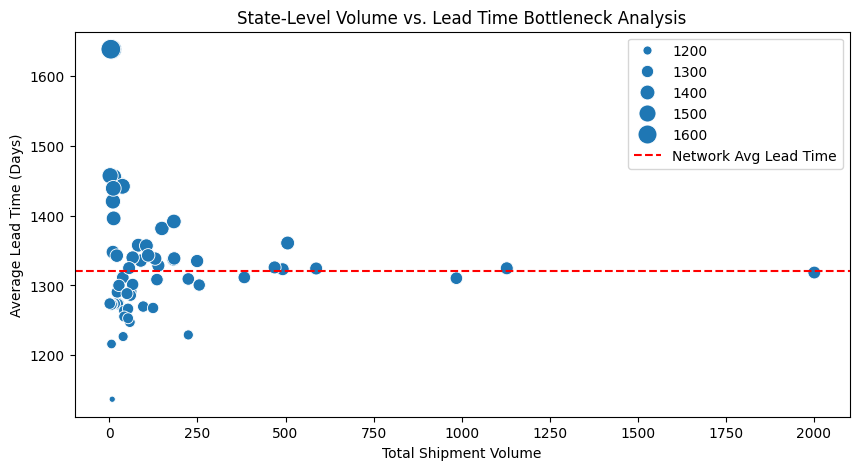

In [ ]:
# Group by destination state to spot regional bottlenecks
state_bottlenecks = df.groupby('State/Province').agg(
    Total_Shipments=('Order ID', 'count'),
    Avg_Lead_Time=('Shipping Lead Time', 'mean')
).reset_index()

# Define structural threshold for a bottleneck: High volume AND higher than average lead time
overall_avg_lead_time = df['Shipping Lead Time'].mean()
median_volume = state_bottlenecks['Total_Shipments'].median()

bottlenecks = state_bottlenecks[
    (state_bottlenecks['Avg_Lead_Time'] > overall_avg_lead_time) &
    (state_bottlenecks['Total_Shipments'] > median_volume)
].sort_values(by='Avg_Lead_Time', ascending=False)

print(f"Overall Network Average Lead Time: {overall_avg_lead_time:.2f} days\n")
print("=== GEOGRAPHIC BOTTLENECK STATES (High Volume & Long Delays) ===")
print(bottlenecks.to_string(index=False))

# Quick Visual Plot for your report
plt.figure(figsize=(10, 5))
sns.scatterplot(data=state_bottlenecks, x='Total_Shipments', y='Avg_Lead_Time', size='Avg_Lead_Time', sizes=(20, 200))
plt.axhline(overall_avg_lead_time, color='red', linestyle='--', label='Network Avg Lead Time')
plt.title('State-Level Volume vs. Lead Time Bottleneck Analysis')
plt.xlabel('Total Shipment Volume')
plt.ylabel('Average Lead Time (Days)')
plt.legend()
plt.show()

=== SHIP MODE PERFORMANCE & TRADE-OFF MATRIX ===
     Ship Mode  Total_Shipments  Avg_Lead_Time  Avg_Sales  Avg_Gross_Profit  Profit_Margin
   First Class             1548    1338.275840  13.772216          9.051092      65.719939
      Same Day              547    1333.442413  13.004881          8.593656      66.080237
  Second Class             1979    1323.845376  14.077928          9.250389      65.708455
Standard Class             6120    1314.334641  13.969011          9.219683      66.000970


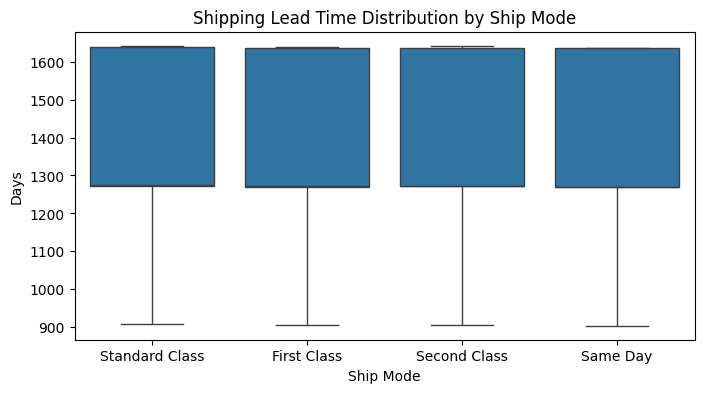

In [ ]:
# Group data by Ship Mode
ship_mode_analysis = df.groupby('Ship Mode').agg(
    Total_Shipments=('Order ID', 'count'),
    Avg_Lead_Time=('Shipping Lead Time', 'mean'),
    Avg_Sales=('Sales', 'mean'),
    Avg_Gross_Profit=('Gross Profit', 'mean'),
    Profit_Margin=('Gross Profit', lambda x: (x.sum() / df.loc[x.index, 'Sales'].sum()) * 100)
).reset_index()

print("=== SHIP MODE PERFORMANCE & TRADE-OFF MATRIX ===")
print(ship_mode_analysis.to_string(index=False))

# Plot performance distribution
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Ship Mode', y='Shipping Lead Time', showfliers=False)
plt.title('Shipping Lead Time Distribution by Ship Mode')
plt.ylabel('Days')
plt.show()

In [ ]:
# Export summaries to Excel files for easy referencing
top_10_routes.to_excel('top_10_routes.xlsx', index=False)
bottom_10_routes.to_excel('bottom_10_routes.xlsx', index=False)
bottlenecks.to_excel('regional_bottlenecks.xlsx', index=False)
ship_mode_analysis.to_excel('ship_mode_analysis.xlsx', index=False)

# Download the files directly to your computer
files.download('top_10_routes.xlsx')
files.download('bottom_10_routes.xlsx')
files.download('regional_bottlenecks.xlsx')
files.download('ship_mode_analysis.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
print(os.listdir('.'))

['.config', 'regional_bottlenecks.xlsx', 'bottom_10_routes.xlsx', 'Final Nassau Candy Distributor (2).xlsx', 'Final Nassau Candy Distributor.xlsx', 'Final Nassau Candy Distributor (1).xlsx', 'top_10_routes.xlsx', 'ship_mode_analysis.xlsx', 'sample_data']


In [ ]:
import pandas as pd

xls = pd.ExcelFile('Final Nassau Candy Distributor.xlsx')
print("Sheet names:", xls.sheet_names)
df = pd.read_excel('Final Nassau Candy Distributor.xlsx')
print(df.info())
print(df.head())

Sheet names: ['Nassau Candy Distributor']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  object        
 7   City            10194 non-null  object        
 8   State/Province  10194 non-null  object        
 9   Postal Code     10194 non-null  object        
 10  Division        10194 non-null  object        
 11  Region          10194 non-null  object        
 12  Product ID      10194 non-null  object        
 13  Product Name    10194 non-null  object        
 14  Sales       

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_excel('Final Nassau Candy Distributor.xlsx')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Shipping Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

print("Lead time summary stats:")
print(df['Shipping Lead Time'].describe())
print("\nUnique Product Names in data:")
print(df['Product Name'].unique())

Lead time summary stats:
count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Shipping Lead Time, dtype: float64

Unique Product Names in data:
['Wonka Bar - Milk Chocolate' 'Wonka Bar - Triple Dazzle Caramel'
 'Wonka Bar - Nutty Crunch Surprise' 'Wonka Bar -Scrumdiddlyumptious'
 'Wonka Bar - Fudge Mallows' 'Wonka Gum' 'Kazookles' 'Lickable Wallpaper'
 'Fizzy Lifting Drinks' 'Laffy Taffy' 'SweeTARTS' 'Nerds' 'Hair Toffee'
 'Everlasting Gobstopper' 'Fun Dip']


In [ ]:
# Let's perform the actual analytical steps requested to grab real numbers for the paper
factory_mapping = {
    'Wonka Bar - Nutty Crunch Surprise': "Lot's O' Nuts",
    'Wonka Bar - Fudge Mallows': "Lot's O' Nuts",
    'Wonka Bar -Scrumdiddlyumptious': "Lot's O' Nuts",
    'Wonka Bar - Milk Chocolate': "Wicked Choccy's",
    'Wonka Bar - Triple Dazzle Caramel': "Wicked Choccy's",
    'Laffy Taffy': 'Sugar Shack',
    'SweeTARTS': 'Sugar Shack',
    'Nerds': 'Sugar Shack',
    'Fun Dip': 'Sugar Shack',
    'Fizzy Lifting Drinks': 'Sugar Shack',
    'Everlasting Gobstopper': 'Secret Factory',
    'Hair Toffee': 'The Other Factory',
    'Lickable Wallpaper': 'Secret Factory',
    'Wonka Gum': 'Secret Factory',
    'Kazookles': 'The Other Factory'
}
df['Factory'] = df['Product Name'].map(factory_mapping)
df['Route_State'] = df['Factory'] + " → " + df['State/Province']

route_metrics = df.groupby('Route_State').agg(
    Total_Shipments=('Order ID', 'count'),
    Avg_Lead_Time=('Shipping Lead Time', 'mean')
).reset_index()

print("Top 5 Fastest Routes:")
print(route_metrics.sort_values(by='Avg_Lead_Time').head(5))

print("\nBottom 5 Slowest Routes:")
print(route_metrics.sort_values(by='Avg_Lead_Time', ascending=False).head(5))

ship_mode_metrics = df.groupby('Ship Mode').agg(
    Total_Shipments=('Order ID', 'count'),
    Avg_Lead_Time=('Shipping Lead Time', 'mean'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Gross Profit', 'sum')
).reset_index()
print("\nShip Mode Metrics:")
print(ship_mode_metrics)

Top 5 Fastest Routes:
                         Route_State  Total_Shipments  Avg_Lead_Time
80       Secret Factory → New Mexico                2          906.0
76         Secret Factory → Nebraska                1          906.0
121    The Other Factory → Louisiana                1          907.0
115  The Other Factory → Connecticut                2          907.5
75      Secret Factory → Mississippi                1          908.0

Bottom 5 Slowest Routes:
                         Route_State  Total_Shipments  Avg_Lead_Time
103         Sugar Shack → New Jersey                1         1642.0
78    Secret Factory → New Hampshire                1         1641.0
98         Sugar Shack → Connecticut                1         1641.0
194  Wicked Choccy's → West Virginia                2         1639.0
37      Lot's O' Nuts → North Dakota                5         1638.2

Ship Mode Metrics:
        Ship Mode  Total_Shipments  Avg_Lead_Time  Total_Sales  Total_Profit
0     First Class          